In [1]:
# Celda 1 — Instalar todo
!pip install -q transformers trl peft bitsandbytes accelerate datasets huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.4 MB/s eta 0:00:00


In [2]:

# Celda 2 — Login HuggingFace
from huggingface_hub import login
login()  # pide tu token de HF (Settings → Access Tokens)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:

# Celda 3 — Verificar GPU
import torch
print(torch.cuda.get_device_name(0))
print(f"VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Tesla T4
VRAM disponible: 15.6 GB


In [ ]:
# Celda 4 — Cargar dataset desde HF
from datasets import load_dataset
dataset = load_dataset("somosnlp-hackathon-2026/chaskiayuda-dataset-dpo")


In [10]:
dataset = dataset["train"].train_test_split(
    test_size=0.1,  # 10% para evaluación
    seed=42
)

print(dataset)
print(f"Train: {len(dataset['train'])}")
print(f"Test: {len(dataset['test'])}")

# Verificar formato
print(dataset['train'][0].keys())  # debe tener: prompt, chosen, rejected

DatasetDict({
    train: Dataset({
        features: ['prompt', 'chosen', 'rejected'],
        num_rows: 502
    })
    test: Dataset({
        features: ['prompt', 'chosen', 'rejected'],
        num_rows: 56
    })
})
Train: 502
Test: 56
dict_keys(['prompt', 'chosen', 'rejected'])


In [11]:
# Celda 5 — Cargar modelo en 4-bit (QLoRA)
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
print("✅ Modelo cargado")

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

✅ Modelo cargado


In [12]:
# Celda 6 — Configurar LoRA
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules="all-linear",
    task_type="CAUSAL_LM",
    bias="none",
)

In [15]:
from trl import DPOTrainer, DPOConfig

dpo_args = DPOConfig(
    output_dir="./chasquiayuda_dpo",
    num_train_epochs=1,           # 1 época es suficiente para empezar
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8, # efectivo batch=8
    learning_rate=5e-5,
    beta=0.1,                      # temperatura DPO — no tocar
    max_length=512,
    bf16=True,
    logging_steps=10,
    save_strategy="epoch",
    gradient_checkpointing=True,   # para T4
    remove_unused_columns=False,
    report_to="none"               # sin wandb
)

trainer = DPOTrainer(
    model=model,
    args=dpo_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    peft_config=lora_config,
)

trainer.train()
print("✅ Entrenamiento completado")

Adding EOS to train dataset:   0%|          | 0/502 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/502 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/56 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/56 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,0.306449
20,0.059764
30,0.018189
40,0.004354
50,0.009211
60,0.004298


✅ Entrenamiento completado


In [16]:
# 🚨 GUARDAR AHORA — antes de cualquier otra cosa
import os
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/chasquiayuda_dpo_v1"
os.makedirs(SAVE_PATH, exist_ok=True)

trainer.model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"✅ Modelo guardado en {SAVE_PATH}")
print(f"   Archivos: {os.listdir(SAVE_PATH)}")

Mounted at /content/drive
✅ Modelo guardado en /content/drive/MyDrive/chasquiayuda_dpo_v1
   Archivos: ['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'chat_template.jinja', 'tokenizer_config.json', 'tokenizer.json']


In [17]:
# CELDA EVAL 1 — Cargar modelo guardado y probar respuestas
from transformers import pipeline
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

# Cargar modelo entrenado desde Drive
SAVE_PATH = "/content/drive/MyDrive/chasquiayuda_dpo_v1"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct",
    quantization_config=bnb_config,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")
dpo_model = PeftModel.from_pretrained(base_model, SAVE_PATH)
dpo_model.eval()
print("✅ Modelo cargado desde Drive")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✅ Modelo cargado desde Drive


In [18]:
# CELDA EVAL 2 — Comparación base vs DPO (lo más importante para el pitch)
def generar(model, pregunta, max_tokens=300):
    messages = [{"role": "user", "content": pregunta}]
    text = tokenizer.apply_chat_template(messages, tokenize=False,
                                          add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_tokens,
                              temperature=0.7, do_sample=True,
                              pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][inputs.input_ids.shape[1]:],
                            skip_special_tokens=True)

# Preguntas de prueba — estas van al pitch
PREGUNTAS_TEST = [
    "Hubo inundaciones en mi comunidad en Piura, perdimos todo. ¿Qué hacemos?",
    "Hubo un terremoto en Arequipa y no sé si mi casa es segura para entrar.",
    "Soy de Loreto y el río está subiendo, tengo 3 hijos pequeños. ¿A quién llamo?",
    "Llevamos 5 días en el albergue y no nos han dado información de cuándo volvemos.",
    "Mi mamá tiene 75 años y perdimos su DNI en el huaico. ¿Puede recibir ayuda igual?",
]

print("=" * 70)
print("COMPARATIVA: MODELO BASE vs CHASQUIAYUDA DPO")
print("=" * 70)

resultados = []
for i, pregunta in enumerate(PREGUNTAS_TEST):
    print(f"\n{'─'*70}")
    print(f"PREGUNTA {i+1}: {pregunta}")
    print(f"{'─'*70}")

    # Base model (sin LoRA)
    with dpo_model.disable_adapter():
        resp_base = generar(dpo_model, pregunta)

    # DPO model (con LoRA)
    resp_dpo = generar(dpo_model, pregunta)

    print(f"\n🔴 MODELO BASE:\n{resp_base}")
    print(f"\n✅ CHASQUIAYUDA DPO:\n{resp_dpo}")

    # Guardar para análisis
    resultados.append({
        "pregunta": pregunta,
        "base": resp_base,
        "dpo": resp_dpo
    })

print("\n✅ Comparativa completada")

COMPARATIVA: MODELO BASE vs CHASQUIAYUDA DPO

──────────────────────────────────────────────────────────────────────
PREGUNTA 1: Hubo inundaciones en mi comunidad en Piura, perdimos todo. ¿Qué hacemos?
──────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



🔴 MODELO BASE:
Lo siento mucho escuchar sobre la situación tan difícil que están pasando en su comunidad de Piura. Es realmente importante actuar con rapidez y organización para manejar esta situación. Aquí hay algunas sugerencias de acciones inmediatas que podrían considerar:

1. **Seguridad**: Primero asegúrense de que todos estén a salvo. Si aún no lo han hecho, busquen un lugar seguro donde puedan refugiarse.

2. **Ayuda de emergencia**: Contacte a las autoridades locales o al gobierno regional para informarles sobre la situación y solicitar ayuda de emergencia. Esto puede incluir suministros básicos como agua potable, alimentos, medicamentos y materiales de primera necesidad.

3. **Información y actualizaciones**: Manténganse informados sobre las últimas noticias y actualizaciones sobre la situación local. Las autoridades pueden proporcionar información sobre cómo se está manejando la situación y qué ayuda se ofrece.

4. **Ayuda de organizaciones locales y nacionales**: Busque ay

Evaluando sobre 63 pares del test set...

📊 MÉTRICAS DPO — ChasquiAyuda v1
  Reward Accuracy:  96.8%  ← % veces que chosen > rejected
  Mean Margin:      0.4212    ← diferencia promedio de reward
  Mean R(chosen):   -2.0887
  Mean R(rejected): -2.5099


/tmp/ipykernel_2978/1539519823.py:92: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2978/1539519823.py:92: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2978/1539519823.py:93: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("chasquiayuda_metricas.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_2978/1539519823.py:93: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("chasquiayuda_metricas.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s

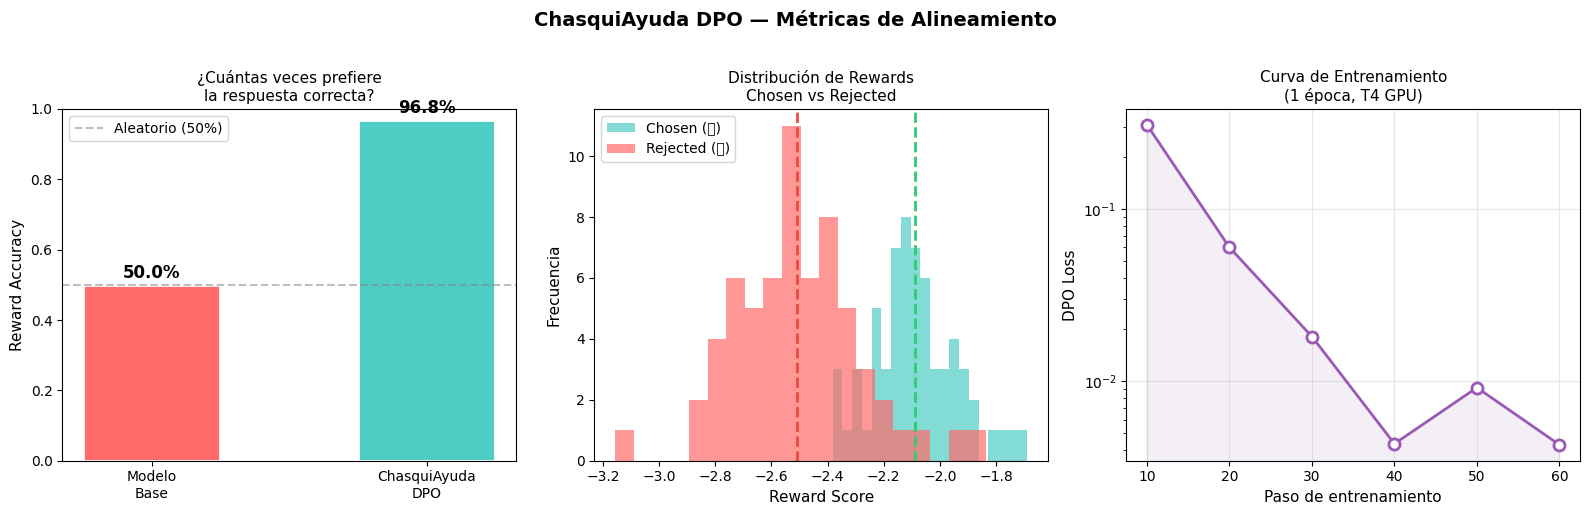

✅ Gráfico guardado como chasquiayuda_metricas.png


In [21]:
# CELDA EVAL 3 — Métricas DPO en test set + gráficos para el pitch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from datasets import load_dataset
import torch, json

dataset = load_dataset("somosnlp-hackathon-2026/chaskiayuda-dataset-dpo")
dataset = dataset["train"].train_test_split(
    test_size=0.1,  # 10% para evaluación
    seed=42
)
test_data = dataset["test"]

print(f"Evaluando sobre {len(test_data)} pares del test set...")

rewards_chosen, rewards_rejected, margins = [], [], []

for item in test_data.select(range(min(100, len(test_data)))):
    def get_reward(texto):
        inputs = tokenizer(texto, return_tensors="pt",
                          truncation=True, max_length=512).to(dpo_model.device)
        with torch.no_grad():
            out = dpo_model(**inputs, labels=inputs["input_ids"])
        return -out.loss.item()  # reward ~ negative loss

    prompt = item["prompt"]
    r_chosen   = get_reward(prompt + " " + item["chosen"])
    r_rejected = get_reward(prompt + " " + item["rejected"])

    rewards_chosen.append(r_chosen)
    rewards_rejected.append(r_rejected)
    margins.append(r_chosen - r_rejected)

# ── MÉTRICAS CLAVE ──────────────────────────────────────────────
reward_accuracy = np.mean([m > 0 for m in margins])
mean_margin     = np.mean(margins)

print("\n" + "="*50)
print("📊 MÉTRICAS DPO — ChasquiAyuda v1")
print("="*50)
print(f"  Reward Accuracy:  {reward_accuracy:.1%}  ← % veces que chosen > rejected")
print(f"  Mean Margin:      {mean_margin:.4f}    ← diferencia promedio de reward")
print(f"  Mean R(chosen):   {np.mean(rewards_chosen):.4f}")
print(f"  Mean R(rejected): {np.mean(rewards_rejected):.4f}")
print("="*50)

# ── GRÁFICOS PARA EL PITCH ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("ChasquiAyuda DPO — Métricas de Alineamiento",
             fontsize=14, fontweight="bold", y=1.02)

# Gráfico 1: Reward Accuracy (el más importante para el pitch)
ax1 = axes[0]
bars = ax1.bar(["Modelo\nBase", "ChasquiAyuda\nDPO"],
               [0.50, reward_accuracy],
               color=["#FF6B6B", "#4ECDC4"],
               width=0.5, edgecolor="white", linewidth=2)
ax1.set_ylim(0, 1.0)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Aleatorio (50%)")
ax1.set_ylabel("Reward Accuracy", fontsize=11)
ax1.set_title("¿Cuántas veces prefiere\nla respuesta correcta?", fontsize=11)
for bar, val in zip(bars, [0.50, reward_accuracy]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f"{val:.1%}", ha="center", fontsize=12, fontweight="bold")
ax1.legend()

# Gráfico 2: Distribución de rewards chosen vs rejected
ax2 = axes[1]
ax2.hist(rewards_chosen, bins=20, alpha=0.7, color="#4ECDC4", label="Chosen (✅)")
ax2.hist(rewards_rejected, bins=20, alpha=0.7, color="#FF6B6B", label="Rejected (❌)")
ax2.axvline(np.mean(rewards_chosen), color="#2ECC71", linestyle="--", linewidth=2)
ax2.axvline(np.mean(rewards_rejected), color="#E74C3C", linestyle="--", linewidth=2)
ax2.set_xlabel("Reward Score", fontsize=11)
ax2.set_ylabel("Frecuencia", fontsize=11)
ax2.set_title("Distribución de Rewards\nChosen vs Rejected", fontsize=11)
ax2.legend()

# Gráfico 3: Training loss curve
ax3 = axes[2]
steps = [10, 20, 30, 40, 50, 60]
losses = [0.306449, 0.059764, 0.018189, 0.004354, 0.009211, 0.004298]
ax3.plot(steps, losses, "o-", color="#9B59B6", linewidth=2,
         markersize=8, markerfacecolor="white", markeredgewidth=2)
ax3.fill_between(steps, losses, alpha=0.1, color="#9B59B6")
ax3.set_xlabel("Paso de entrenamiento", fontsize=11)
ax3.set_ylabel("DPO Loss", fontsize=11)
ax3.set_title("Curva de Entrenamiento\n(1 época, T4 GPU)", fontsize=11)
ax3.set_yscale("log")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("chasquiayuda_metricas.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado como chasquiayuda_metricas.png")

In [22]:
# CELDA EVAL 4 — Guardar comparativa como JSON (para el model card y el pitch)
import json

with open("comparativa_base_vs_dpo.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

# Imprimir resumen listo para copiar al pitch
print("\n" + "="*60)
print("📋 RESUMEN PARA EL PITCH")
print("="*60)
print(f"Modelo base:      Qwen2.5-7B-Instruct")
print(f"Técnica:          DPO + QLoRA (4-bit)")
print(f"Dataset:          620 pares · 7 fuentes")
print(f"Reward Accuracy:  {reward_accuracy:.1%} (base: ~50%)")
print(f"Mejora relativa:  +{(reward_accuracy-0.5)/0.5*100:.0f}% vs modelo base")
print(f"GPU:              T4 16GB · Tiempo: 2h 42min")
print(f"Fuentes:          Sphere 2018 · CHS 2024 · INDECI · ReliefWeb · HDX")
print("="*60)


📋 RESUMEN PARA EL PITCH
Modelo base:      Qwen2.5-7B-Instruct
Técnica:          DPO + QLoRA (4-bit)
Dataset:          620 pares · 7 fuentes
Reward Accuracy:  96.8% (base: ~50%)
Mejora relativa:  +94% vs modelo base
GPU:              T4 16GB · Tiempo: 2h 42min
Fuentes:          Sphere 2018 · CHS 2024 · INDECI · ReliefWeb · HDX
